11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Test data shape: (10000, 784)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8724 - loss: 0.4441 - val_accuracy: 0.9698 - val_loss: 0.1078
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9666 - loss: 0.1149 - val_accuracy: 0.9678 - val_loss: 0.1050
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9766 - loss: 0.0755 - val_accuracy: 0.9765 - val_loss: 0.0844
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9813 - loss: 0.0576 - val_accuracy: 0.9758 - val_loss: 0.0848
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9869 - loss: 0.0406 - val_accuracy: 0.9737 - val_loss: 0.0950
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9886 - loss: 0.0322 - val_accuracy: 0.9767 - val_loss: 0.0878
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9917 - loss: 0.0264 - val_accuracy: 0.9772 - val_loss: 0.0845
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9929 - loss: 0.0223 - 

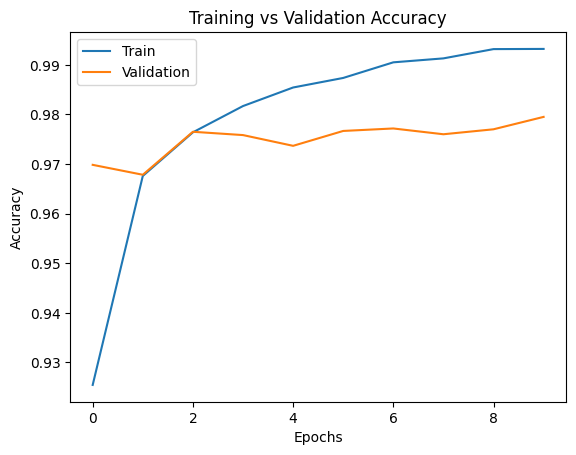

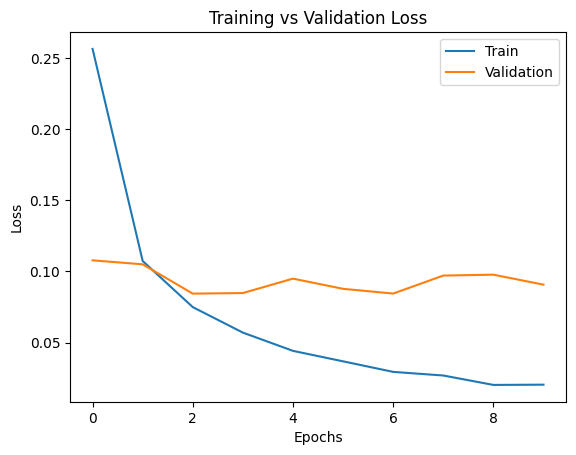

In [ ]:
# Case Study: MNIST Classification using MLP
# ==========================================

# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# ==========================================
# 2. Load and Preprocess Dataset
# ==========================================

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# ==========================================
# 3. Define MLP Model Architecture
# ==========================================

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),  # Hidden layer
    Dense(64, activation='relu'),                       # Hidden layer
    Dense(10, activation='softmax')                     # Output layer
])

# ==========================================
# 4. Compile Model
# ==========================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 5. Train Model
# ==========================================

history = model.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# ==========================================
# 6. Evaluate Model
# ==========================================

test_loss, test_acc = model.evaluate(x_test, y_test_cat)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_acc)

# ==========================================
# 7. Visualization
# ==========================================

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()